# Classification Algorithms

## All Classification Algorithms applied on Iris dataset

### Objective: Predict species based on sepal and petal length/width

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


# Exploratory data Analysis

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [7]:
data["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
species_mapping = {"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2}
data["Species_encoded"] = data["Species"].map(species_mapping)

In [9]:
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_encoded
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,2
146,147,6.3,2.5,5.0,1.9,Iris-virginica,2
147,148,6.5,3.0,5.2,2.0,Iris-virginica,2
148,149,6.2,3.4,5.4,2.3,Iris-virginica,2


In [10]:
X = data [['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data ["Species"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30)

# Creating first model Using Logistic Regression:

In [13]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train,y_train)
y_pred = logreg.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9111111111111111

In [15]:
y_proba = logreg.predict_proba(X_test)

# Model evaluation

In [16]:
from sklearn.metrics import classification_report

In [17]:
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       0.89      0.89      0.89        18
 Iris-virginica       0.86      0.86      0.86        14

       accuracy                           0.91        45
      macro avg       0.92      0.92      0.92        45
   weighted avg       0.91      0.91      0.91        45



In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[13,  0,  0],
       [ 0, 16,  2],
       [ 0,  2, 12]])

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

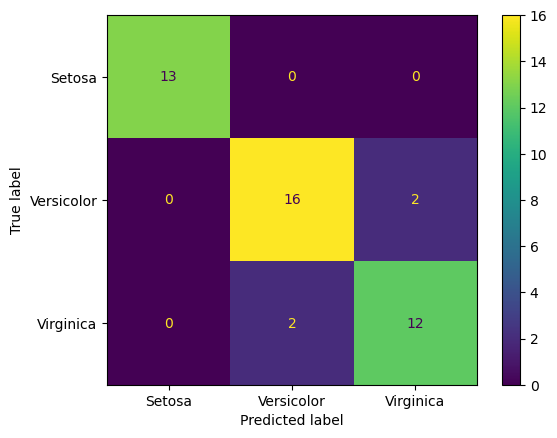

In [21]:
disp = ConfusionMatrixDisplay(cm,display_labels = ["Setosa","Versicolor","Virginica"])
disp.plot()
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test,y_proba,multi_class="ovr")

In [23]:
print(roc_auc)

0.9912764787316758


# Decision Trees Model:

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30)
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test,y_pred_dt))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        16
Iris-versicolor       0.83      0.77      0.80        13
 Iris-virginica       0.82      0.88      0.85        16

       accuracy                           0.89        45
      macro avg       0.89      0.88      0.88        45
   weighted avg       0.89      0.89      0.89        45



# # Decision Trees Model with Hyperparameter Tuning

Hyperparameters are parameters which control how the model learns and creates the model

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30)

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test,y_pred_dt))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      0.95      0.98        21
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.98        45
      macro avg       0.97      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



# Ensemble Modelling - Random Forest Model

In [102]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test,y_pred_rf))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        18
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.91      0.83      0.87        12

       accuracy                           0.93        45
      macro avg       0.93      0.92      0.92        45
   weighted avg       0.93      0.93      0.93        45



# Random Forest Model with Hyperparameter Tuning

In [150]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,max_depth=10)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test,y_pred_rf))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.94      0.94      0.94        18

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



# KNN - K nearest neighbors

In [152]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

print(classification_report(y_test,y_pred_knn))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.90      1.00      0.95        18

       accuracy                           0.96        45
      macro avg       0.97      0.95      0.95        45
   weighted avg       0.96      0.96      0.95        45



# Naive Bayes 

In [153]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train,y_train)
y_pred_gnb = gnb.predict(X_test)

print(classification_report(y_test,y_pred_gnb))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.94      0.94      0.94        18

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



# Support Vector Machines - SVM

In [154]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train,y_train)
y_pred_svm = svm.predict(X_test)

print(classification_report(y_test,y_pred_svm))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.94      0.97        18

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



# SVM with hyperparameter tuning

In [155]:
from sklearn.svm import SVC

svm = SVC(kernel='poly')
svm.fit(X_train,y_train)
y_pred_svm = svm.predict(X_test)

print(classification_report(y_test,y_pred_svm))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.90      1.00      0.95        18

       accuracy                           0.96        45
      macro avg       0.97      0.95      0.95        45
   weighted avg       0.96      0.96      0.95        45



# Preferable to scale the data in algorithms where distance calculation is involved:

### Creating KNN model with scaled data

In [156]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [157]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled,y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test,y_pred_knn))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.94      0.97        18

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



# Boosting Algorithms:

## Adaboost

In [160]:
from sklearn.ensemble import AdaBoostClassifier

dt = DecisionTreeClassifier(max_depth=1)

adaboost = AdaBoostClassifier(estimator = dt,n_estimators = 100)
adaboost.fit(X_train,y_train)
y_pred_ada = adaboost.predict(X_test)

print(classification_report(y_test,y_pred_ada))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        14
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.94      0.94      0.94        18

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



C:\Users\alkap\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


# PCA - Principal Component Analysis for Dimensionality Reduction

#### Important note: PCA is applied only on x variables, the x variables should be scaled, no of principal components generated is equal to the no of x variables , then we need to finalize the no of components that we want to consider

In [204]:
species_mapping = {"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2}
data["Species_encoded"] = data["Species"].map(species_mapping)

In [205]:
data1 = data[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]]
data1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [206]:
X_original = data1.copy()
scaler2 = StandardScaler()
x = scaler2.fit_transform(X_original)

In [207]:
y = data["Species"]

In [208]:
from sklearn.decomposition import PCA

pca = PCA()

In [209]:
pca.fit(x)

PCA()

In [210]:
pca.components_

array([[ 0.52237162, -0.26335492,  0.58125401,  0.56561105],
       [ 0.37231836,  0.92555649,  0.02109478,  0.06541577],
       [ 0.72101681, -0.24203288, -0.14089226, -0.6338014 ],
       [-0.26199559,  0.12413481,  0.80115427, -0.52354627]])

In [211]:
pca.explained_variance_ratio_

array([0.72770452, 0.23030523, 0.03683832, 0.00515193])

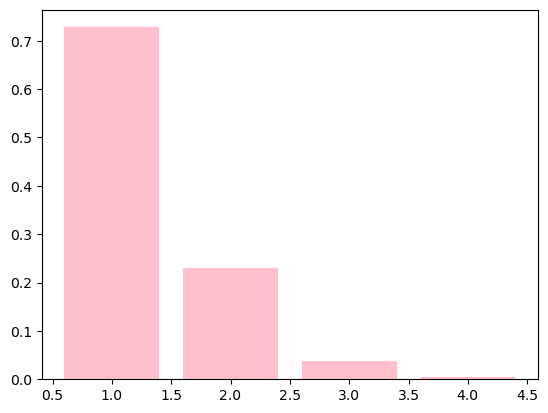

In [212]:
plt.bar(range(1,5),pca.explained_variance_ratio_,color="pink")
plt.show()

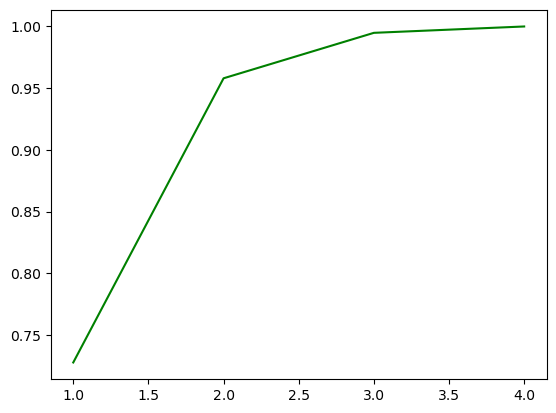

In [213]:
var_cumu = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1,len(var_cumu)+1),var_cumu,color="green")
plt.show()

In [195]:
# Now represent data in 2 PCs

In [214]:
pc2 = PCA(n_components=2)
new = pc2.fit_transform(x)

In [215]:
df = pd.DataFrame(new,columns=["PC1","PC2"])

In [216]:
df

,PC1,PC2
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767
...,...,...
145,1.870522,0.382822
146,1.558492,-0.905314
147,1.520845,0.266795
148,1.376391,1.016362


In [217]:
y.shape

(150,)

In [218]:
df_final = pd.concat([df,y],axis=1)
df_final

,PC1,PC2,Species
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa
...,...,...,...
145,1.870522,0.382822,Iris-virginica
146,1.558492,-0.905314,Iris-virginica
147,1.520845,0.266795,Iris-virginica
148,1.376391,1.016362,Iris-virginica


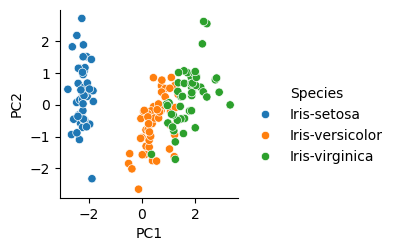

In [219]:
sns.pairplot(data=df_final,x_vars=["PC1"],y_vars=["PC2"],hue="Species")
plt.show()

In [220]:
X = df_final[["PC1","PC2"]]
y = df_final["Species"]

In [221]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30)

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test,y_pred_dt))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.73      0.81        15
 Iris-virginica       0.81      0.94      0.87        18

       accuracy                           0.89        45
      macro avg       0.91      0.89      0.90        45
   weighted avg       0.90      0.89      0.89        45

